In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
population = np.array([10,12,15,18,20,22,25,28,30,35,
                       40,45,50,60,70,80,100,120,150,200])

In [6]:
pop_mean = np.mean(population)
print("Population mean:",pop_mean)
pop_std = np.std(population)
print("Population Standard Deviation:",pop_std)


Population mean: 56.5
Population Standard Deviation: 49.64423430772198


In [15]:
n = 5
sample_means = [np.mean(np.random.choice(population,size = n , replace = True)) for i in range(1000)]
sample_means = np.array(sample_means)
point_of_est = round(np.mean(sample_means),2)

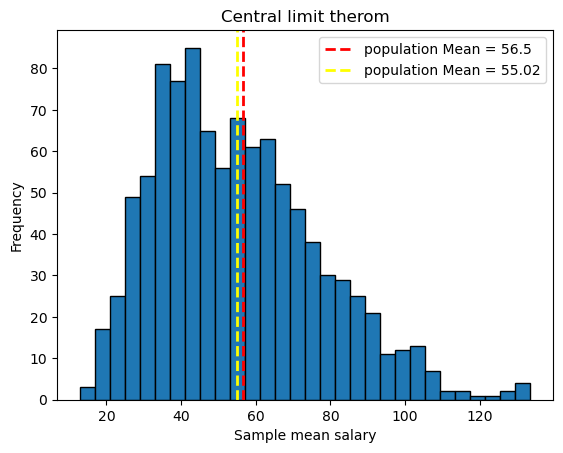

In [23]:
plt.hist(sample_means,bins = 30,edgecolor = 'black')
plt.axvline(pop_mean,color = 'r' , linestyle = '--',linewidth = 2,label = f"population Mean = {round(pop_mean,2)}")
plt.axvline(point_of_est,color = 'yellow' , linestyle = '--',linewidth = 2,label = f"population Mean = {round(point_of_est,2)}")
plt.title("Central limit therom")
plt.xlabel("Sample mean salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Standard Error

In [24]:
Standard_error = pop_std/np.sqrt(n)
print("Standard Error:",Standard_error)

Standard Error: 22.20157652059871


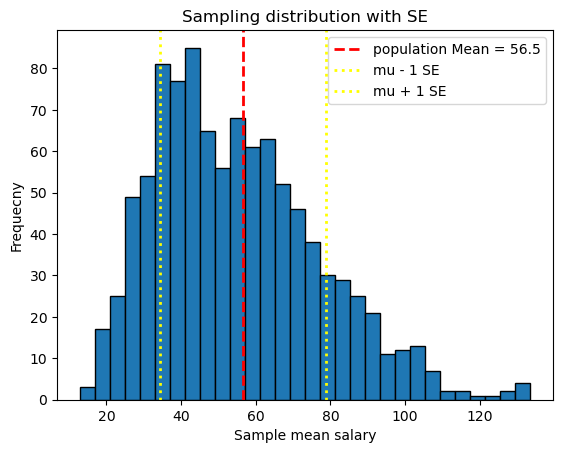

In [27]:
plt.hist(sample_means,bins = 30,edgecolor = 'black')
plt.axvline(pop_mean,color = 'r' , linestyle = '--',linewidth = 2,label = f"population Mean = {round(pop_mean,2)}")
plt.axvline(pop_mean - Standard_error,color = "yellow",linestyle = 'dotted',linewidth = 2,label = "mu - 1 SE")
plt.axvline(pop_mean + Standard_error,color = "yellow",linestyle = 'dotted',linewidth = 2,label = "mu + 1 SE")
plt.title("Sampling distribution with SE")
plt.xlabel("Sample mean salary")
plt.ylabel("Frequecny")
plt.legend()
plt.show()

In [28]:
from scipy import stats
z_critical = stats.norm.ppf(0.975)
z_critical

np.float64(1.959963984540054)

## Confidence Interval

In [35]:
sample_mean = 165
pop_std = 10
n = 50
confidence = 0.95

alpha = 1-confidence
alpha_over_2 = alpha/2

z_critical = stats.norm.ppf(1 - alpha_over_2)
print(f"Z_0.025 = {z_critical:.2f}")

margin_of_error = z_critical * (pop_std / np.sqrt(n))
print(margin_of_error)

CI_lower = sample_mean - margin_of_error
CI_upper = sample_mean + margin_of_error

print(f"95% Confidence Interval:({CI_lower:.2f} to {CI_upper:.2f})")

Z_0.025 = 1.96
2.7718076486993555
95% Confidence Interval:(162.23 to 167.77)


In [38]:
confidence = 0.95
alpha = 1 - confidence
df = 24

t_critical = stats.t.ppf(1-alpha/2,df)
t_critical

np.float64(2.0638985616280205)

Sample Size (n): 25
Sample Mean (X̄): 59.12
Sample SD (s): 2.13
Degrees of Freedom (df): 24

Confidence Level: 0.95
Alpha (α): 0.050000000000000044
Alpha/2 (α/2): 0.025000000000000022

t-critical value (t_α/2, df): 2.064
Margin of Error (ME): 0.878
Confidence Interval (CI): (58.24, 60.00) kg


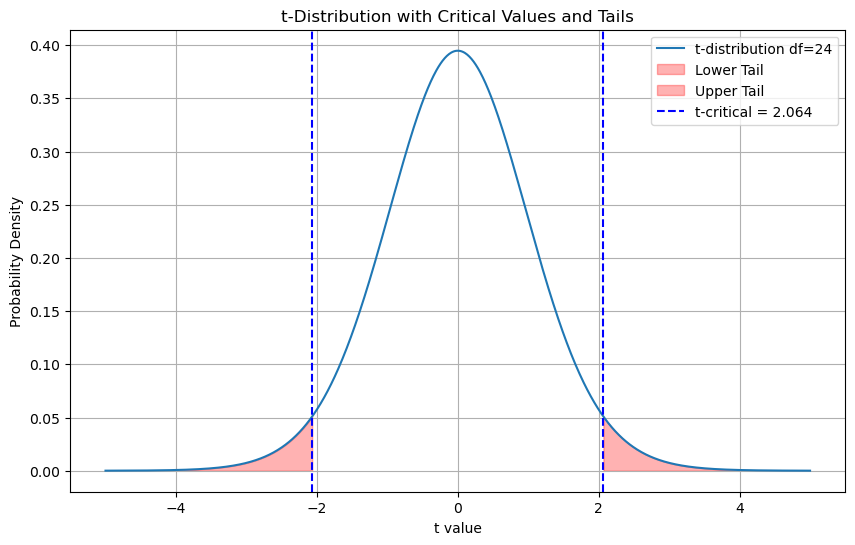

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# Step 1: Sample Data
# -----------------------------
weights = np.array([
    55, 60, 58, 62, 59, 57, 61, 56, 63, 60, 
    58, 59, 62, 57, 61, 60, 56, 58, 59, 61, 
    57, 60, 58, 59, 62
])

n = len(weights)                  # Sample size
sample_mean = np.mean(weights)    # Sample mean
sample_std = np.std(weights, ddof=1)  # Sample standard deviation (ddof=1 for sample SD)
df = n - 1                        # Degrees of freedom

print("Sample Size (n):", n)
print("Sample Mean (X̄):", round(sample_mean,2))
print("Sample SD (s):", round(sample_std,2))
print("Degrees of Freedom (df):", df)

# -----------------------------
# Step 2: Confidence Level
# -----------------------------
confidence = 0.95
alpha = 1 - confidence
alpha_half = alpha / 2

print("\nConfidence Level:", confidence)
print("Alpha (α):", alpha)
print("Alpha/2 (α/2):", alpha_half)

# -----------------------------
# Step 3: t-critical value
# -----------------------------
t_critical = stats.t.ppf(1 - alpha_half, df)
print("\nt-critical value (t_α/2, df):", round(t_critical,3))

# -----------------------------
# Step 4: Margin of Error
# -----------------------------
ME = t_critical * (sample_std / np.sqrt(n))
print("Margin of Error (ME):", round(ME,3))

# -----------------------------
# Step 5: Confidence Interval
# -----------------------------
CI_lower = sample_mean - ME
CI_upper = sample_mean + ME
print("Confidence Interval (CI): ({:.2f}, {:.2f}) kg".format(CI_lower, CI_upper))

# -----------------------------
# Step 6: Visualization of t-distribution
# -----------------------------
x = np.linspace(-5, 5, 1000)
t_dist = stats.t.pdf(x, df)

plt.figure(figsize=(10,6))
plt.plot(x, t_dist, label=f't-distribution df={df}')

# Fill the two tails
plt.fill_between(x, t_dist, 0, where=(x <= -t_critical), color='red', alpha=0.3, label='Lower Tail')
plt.fill_between(x, t_dist, 0, where=(x >= t_critical), color='red', alpha=0.3, label='Upper Tail')

# Show t-critical lines
plt.axvline(t_critical, color='blue', linestyle='--', label=f't-critical = {round(t_critical,3)}')
plt.axvline(-t_critical, color='blue', linestyle='--')

plt.title('t-Distribution with Critical Values and Tails')
plt.xlabel('t value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()